## Task 1: Import Required Libraries

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Task 2: Load the Dataset

In [8]:
# Load dataset
df = pd.read_csv('../data/Mall_Customers.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# Dataset info
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Task 3: Data Preprocessing

In [10]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print("\n✅ No missing values found — dataset is clean!")

Missing Values per Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ No missing values found — dataset is clean!


In [11]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Encode Gender for reference (not used in clustering)
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Distribution of Gender
print("\nGender Distribution:")
print(df['Gender'].value_counts())

Duplicate rows: 0

Gender Distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64


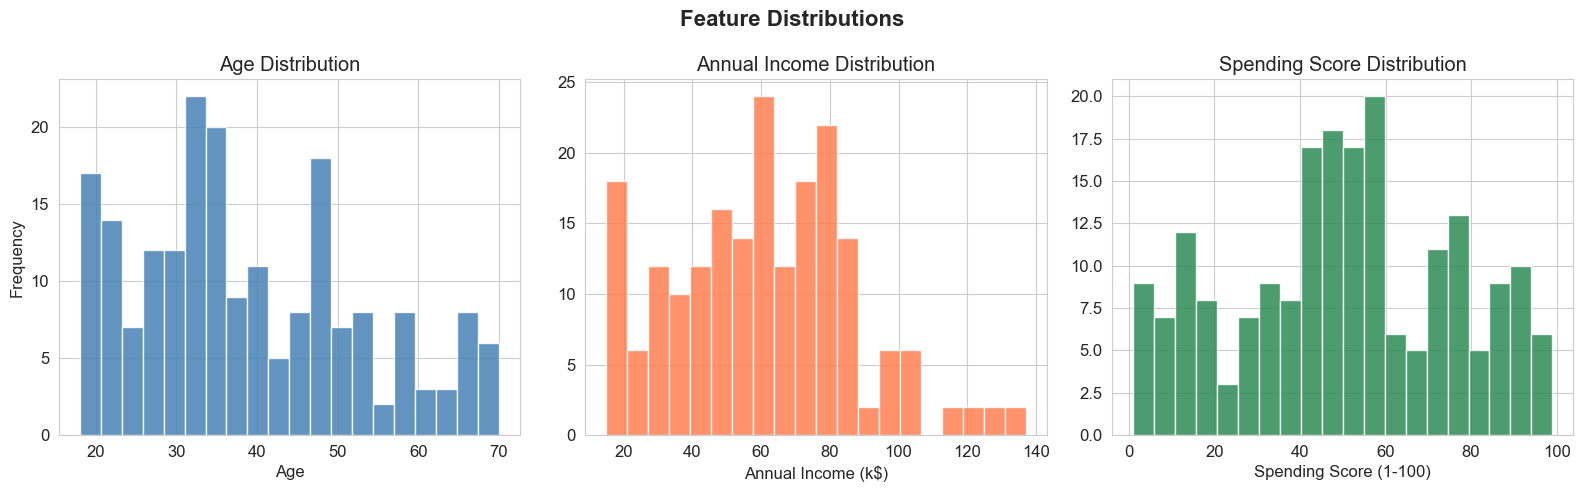

In [ ]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 5))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score (1-100)')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 4: Feature Selection & Scaling

In [13]:
# ─── 2D Features: Annual Income + Spending Score ───
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# ─── 3D Features: Annual Income + Spending Score + Age ───
X_3d = df[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].values

# Scale features using StandardScaler
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

print("2D Feature Matrix shape:", X_2d_scaled.shape)
print("3D Feature Matrix shape:", X_3d_scaled.shape)
print("\nScaled 2D Features (first 5 rows):")
print(pd.DataFrame(X_2d_scaled, columns=['Income_scaled', 'SpendingScore_scaled']).head())

2D Feature Matrix shape: (200, 2)
3D Feature Matrix shape: (200, 3)

Scaled 2D Features (first 5 rows):
   Income_scaled  SpendingScore_scaled
0      -1.738999             -0.434801
1      -1.738999              1.195704
2      -1.700830             -1.715913
3      -1.700830              1.040418
4      -1.662660             -0.395980


## Task 5: Elbow Method to Determine Optimal K

In [14]:
# ─── Elbow Method on 2D Features ───
inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_2d_scaled)
    inertia_values.append(kmeans.inertia_)
    score = silhouette_score(X_2d_scaled, kmeans.labels_)
    silhouette_values.append(score)
    print(f"K={k:2d} | Inertia: {kmeans.inertia_:8.2f} | Silhouette Score: {score:.4f}")

print("\n✅ Elbow Method complete!")

K= 2 | Inertia:   269.69 | Silhouette Score: 0.3213
K= 3 | Inertia:   157.70 | Silhouette Score: 0.4666
K= 4 | Inertia:   108.92 | Silhouette Score: 0.4939
K= 5 | Inertia:    65.57 | Silhouette Score: 0.5547
K= 6 | Inertia:    55.06 | Silhouette Score: 0.5399
K= 7 | Inertia:    44.86 | Silhouette Score: 0.5281
K= 8 | Inertia:    37.23 | Silhouette Score: 0.4552
K= 9 | Inertia:    32.39 | Silhouette Score: 0.4571
K=10 | Inertia:    29.98 | Silhouette Score: 0.4432

✅ Elbow Method complete!


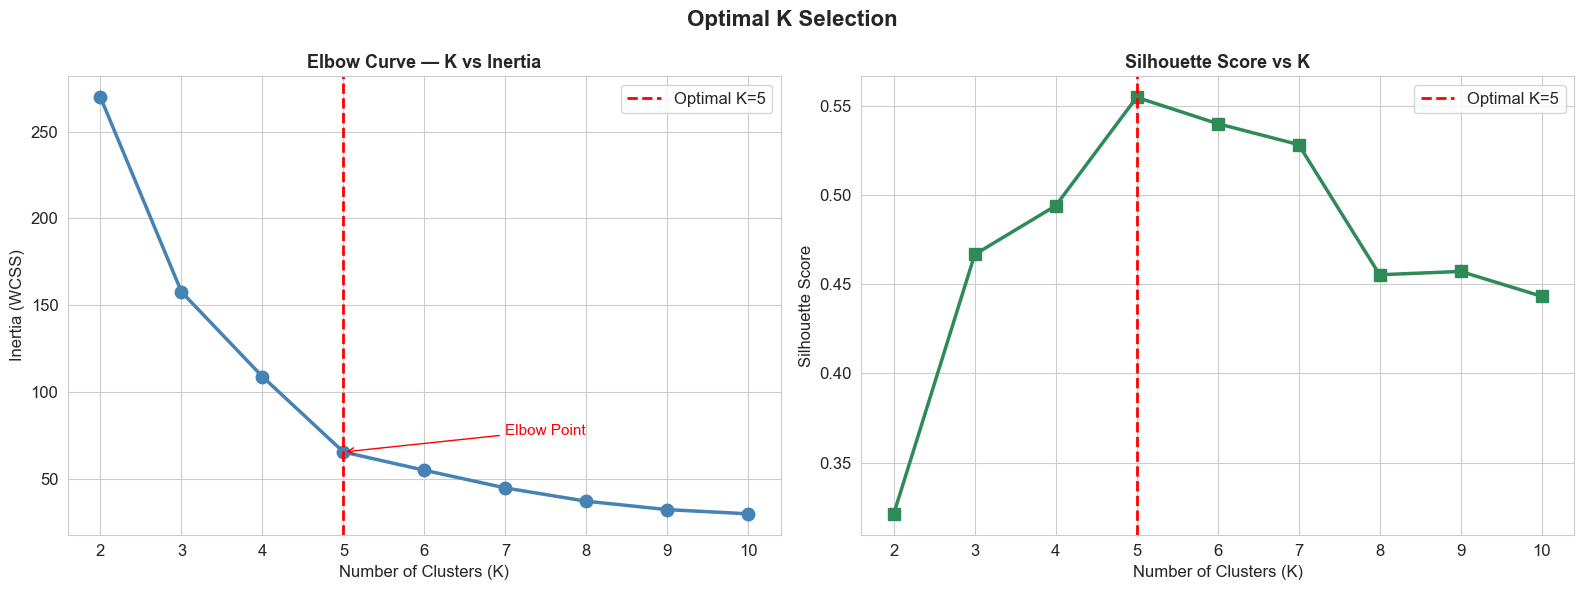


📌 Best Silhouette Score: 0.5547 at K=5


In [15]:
# ─── Plot Elbow Curve + Silhouette Scores ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimal K Selection', fontsize=16, fontweight='bold')

# Elbow Curve
axes[0].plot(list(K_range), inertia_values, 'bo-', linewidth=2.5, markersize=9, color='steelblue')
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
axes[0].set_title('Elbow Curve — K vs Inertia', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()
axes[0].set_xticks(list(K_range))

# Annotate elbow point
axes[0].annotate('Elbow Point', xy=(5, inertia_values[3]),
                 xytext=(7, inertia_values[3] + 10),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=11, color='red')

# Silhouette Score
axes[1].plot(list(K_range), silhouette_values, 'gs-', linewidth=2.5, markersize=9, color='seagreen')
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('elbow_silhouette_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📌 Best Silhouette Score: {max(silhouette_values):.4f} at K={list(K_range)[silhouette_values.index(max(silhouette_values))]}")

## Task 6 & 7: Apply K-Means Clustering & Assign Labels

In [16]:
# ─── Apply K-Means with optimal K=5 (2D) ───
OPTIMAL_K = 5

kmeans_2d = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster_2D'] = kmeans_2d.fit_predict(X_2d_scaled)

# Centroids (inverse transform back to original scale)
centroids_2d = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
centroids_df = pd.DataFrame(centroids_2d, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centroids_df.index.name = 'Cluster'

print(f"K-Means (K={OPTIMAL_K}) Cluster Centroids:")
print(centroids_df.round(2))

print(f"\nFinal Inertia : {kmeans_2d.inertia_:.4f}")
print(f"Silhouette Score: {silhouette_score(X_2d_scaled, kmeans_2d.labels_):.4f}")
print(f"\nCluster Counts:")
print(df['Cluster_2D'].value_counts().sort_index())

K-Means (K=5) Cluster Centroids:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91

Final Inertia : 65.5684
Silhouette Score: 0.5547

Cluster Counts:
Cluster_2D
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Task 8: Visualize Clusters

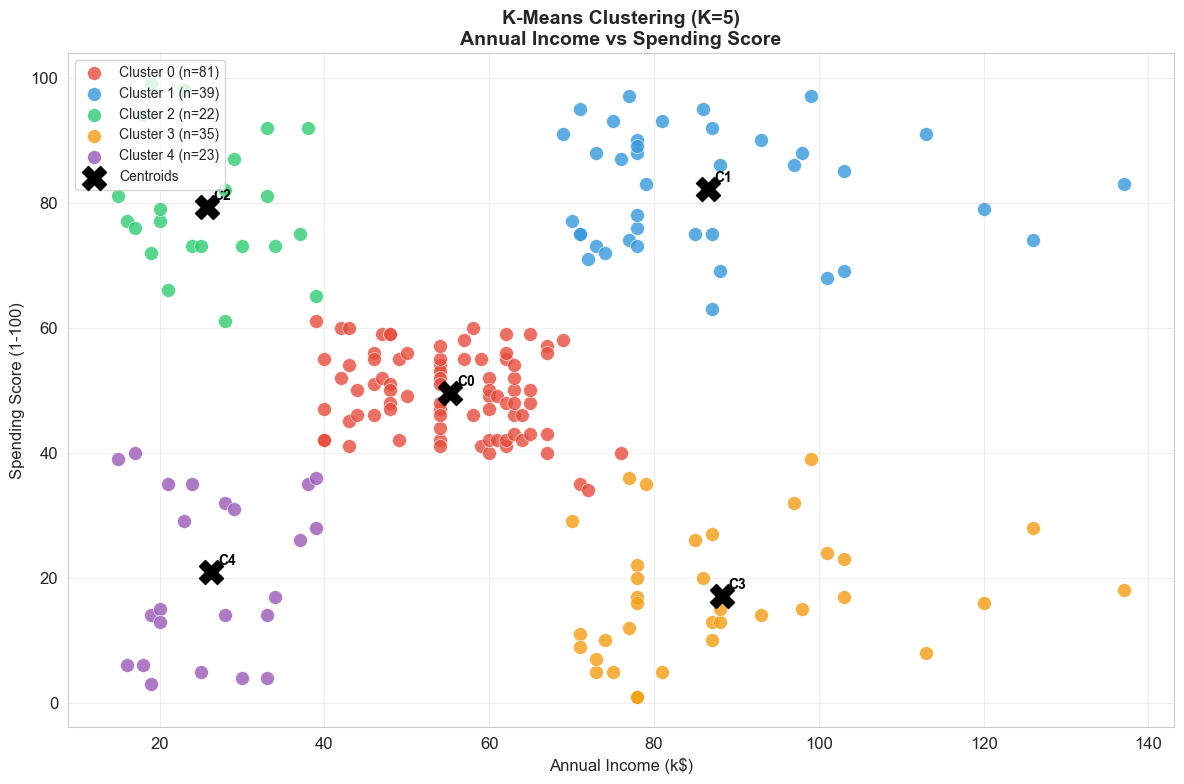

In [17]:
# ─── Scatter Plot: Clusters (Income vs Spending Score) ───
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
segment_names = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3', 4: 'Cluster 4'
}

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster_2D'] == cluster_id
    ax.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id} (n={mask.sum()})',
        s=100, alpha=0.8, edgecolors='white', linewidths=0.5
    )

# Plot centroids
ax.scatter(
    centroids_df['Annual Income (k$)'],
    centroids_df['Spending Score (1-100)'],
    c='black', marker='X', s=300, zorder=5, label='Centroids'
)

# Annotate centroids
for i, row in centroids_df.iterrows():
    ax.annotate(f'C{i}', xy=(row['Annual Income (k$)'], row['Spending Score (1-100)']),
                fontsize=10, fontweight='bold', color='black',
                xytext=(5, 5), textcoords='offset points')

ax.set_title(f'K-Means Clustering (K={OPTIMAL_K})\nAnnual Income vs Spending Score',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_scatter_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 9: Interpret Cluster Characteristics

In [19]:
# ─── Cluster Profile Summary ───
cluster_profile = df.groupby('Cluster_2D').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_SpendingScore=('Spending Score (1-100)', 'mean'),
    Pct_Female=('Gender_Encoded', 'mean')
).round(2)

cluster_profile['Pct_Female'] = (cluster_profile['Pct_Female'] * 100).round(1)
print("Cluster Profile Summary:")
print(cluster_profile)

# Customer Segment Labels based on Income & Spending Score
segment_labels = {
    0: '💰 High Income, Low Spenders (Careful/Savers)',
    1: '🌟 High Income, High Spenders (Target Customers)',
    2: '😐 Moderate Income, Moderate Spenders (Average)',
    3: '💸 Low Income, High Spenders (Impulsive Buyers)',
    4: '🧾 Low Income, Low Spenders (Budget Conscious)'
}

print("\n📌 Customer Segment Interpretation:")
for k, v in segment_labels.items():
    print(f"  Cluster {k}: {v}")

Cluster Profile Summary:
            Count  Avg_Age  Avg_Income  Avg_SpendingScore  Pct_Female
Cluster_2D                                                           
0              81    42.72       55.30              49.52        59.0
1              39    32.69       86.54              82.13        54.0
2              22    25.27       25.73              79.36        59.0
3              35    41.11       88.20              17.11        46.0
4              23    45.22       26.30              20.91        61.0

📌 Customer Segment Interpretation:
  Cluster 0: 💰 High Income, Low Spenders (Careful/Savers)
  Cluster 1: 🌟 High Income, High Spenders (Target Customers)
  Cluster 2: 😐 Moderate Income, Moderate Spenders (Average)
  Cluster 3: 💸 Low Income, High Spenders (Impulsive Buyers)
  Cluster 4: 🧾 Low Income, Low Spenders (Budget Conscious)


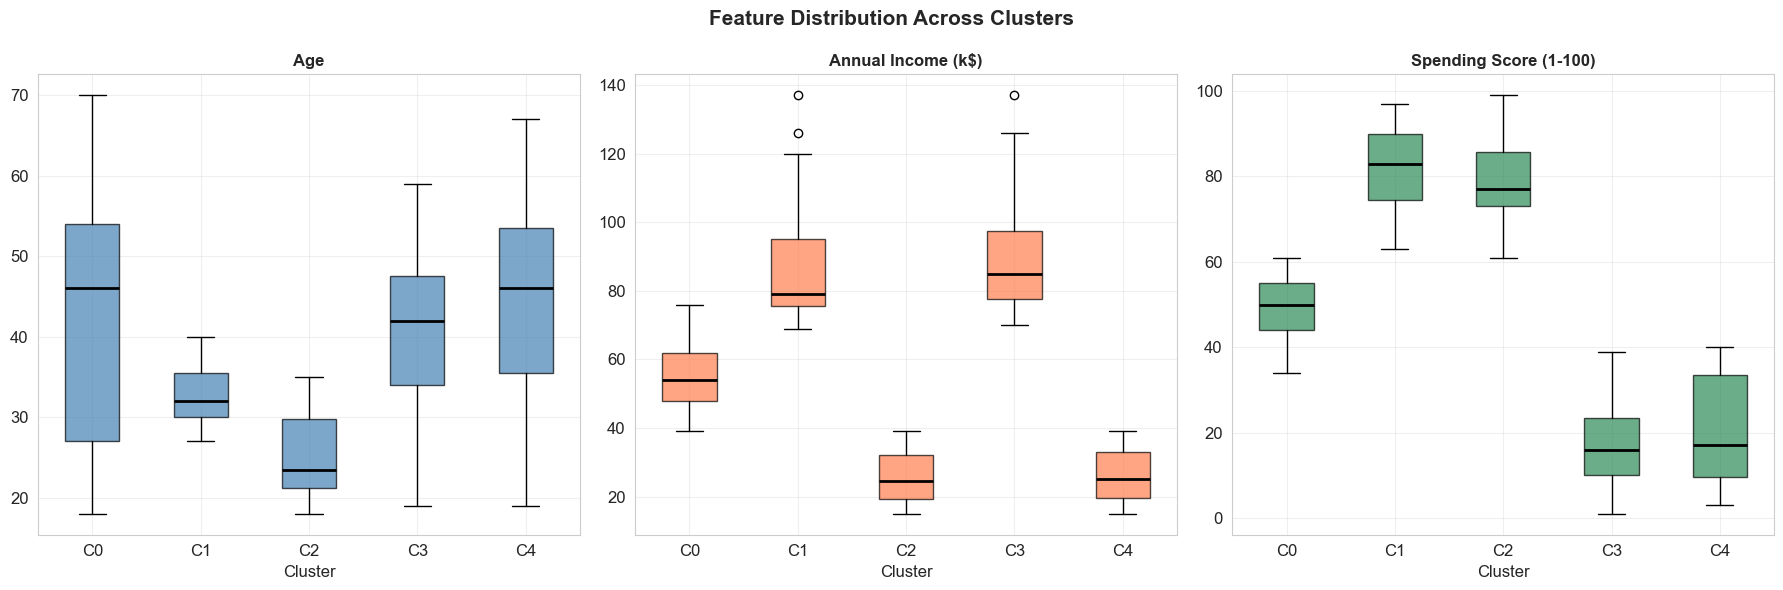

In [20]:
# ─── Cluster Feature Box Plots ───
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Distribution Across Clusters', fontsize=15, fontweight='bold')

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
feat_colors = ['steelblue', 'coral', 'seagreen']

for i, (feat, col) in enumerate(zip(features, feat_colors)):
    data_by_cluster = [df[df['Cluster_2D'] == c][feat].values for c in range(OPTIMAL_K)]
    bp = axes[i].boxplot(data_by_cluster, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticklabels([f'C{c}' for c in range(OPTIMAL_K)])
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis Task: Sensitivity to Initialization (Random vs K-Means++)

In [21]:
# ─── Compare random init vs k-means++ ───
print("📊 Sensitivity to Initialization (K=5)")
print("-" * 55)
print(f"{'Init Method':<15} {'Inertia':>12} {'Silhouette':>14}")
print("-" * 55)

for init_method in ['k-means++', 'random']:
    inertias, sil_scores = [], []
    for seed in range(10):
        km = KMeans(n_clusters=5, init=init_method, n_init=1, random_state=seed)
        km.fit(X_2d_scaled)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X_2d_scaled, km.labels_))
    print(f"{init_method:<15} {np.mean(inertias):>12.3f} {np.mean(sil_scores):>14.4f}")
    print(f"{'Std Dev':<15} {np.std(inertias):>12.3f} {np.std(sil_scores):>14.4f}")
    print()

print("✅ k-means++ provides more stable and better results than random init")

📊 Sensitivity to Initialization (K=5)
-------------------------------------------------------
Init Method          Inertia     Silhouette
-------------------------------------------------------
k-means++             72.210         0.5356
Std Dev               13.272         0.0374

random                83.636         0.5008
Std Dev               23.808         0.0729

✅ k-means++ provides more stable and better results than random init


## Bonus: 3D Clustering (with Age)

3D Clustering Silhouette Score: 0.4166
3D Clustering Inertia        : 168.2476


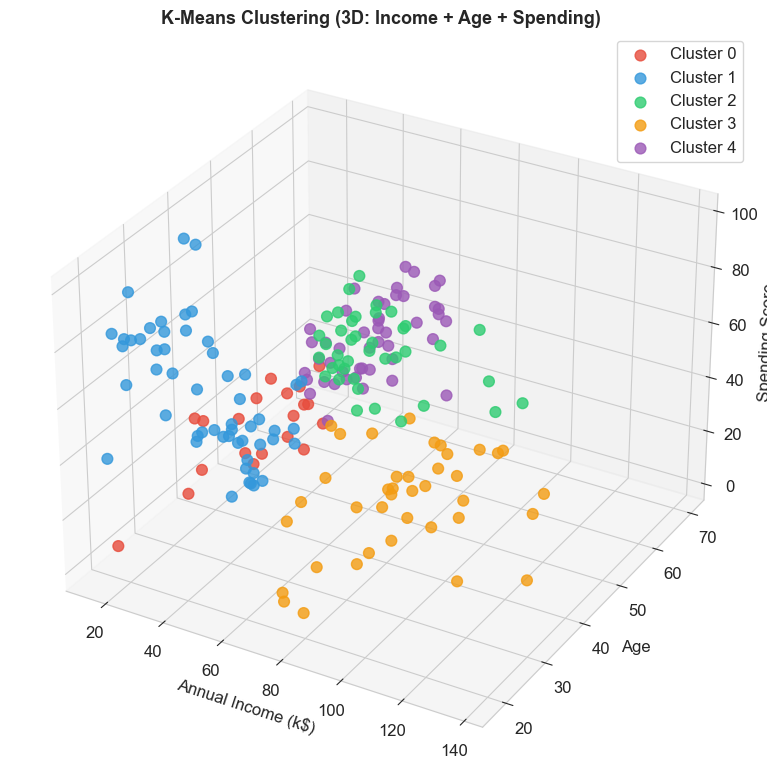

In [22]:
# ─── K-Means with 3D features ───
kmeans_3d = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster_3D'] = kmeans_3d.fit_predict(X_3d_scaled)

sil_3d = silhouette_score(X_3d_scaled, kmeans_3d.labels_)
print(f"3D Clustering Silhouette Score: {sil_3d:.4f}")
print(f"3D Clustering Inertia        : {kmeans_3d.inertia_:.4f}")

# 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(OPTIMAL_K):
    mask = df['Cluster_3D'] == c
    ax.scatter(df.loc[mask, 'Annual Income (k$)'],
               df.loc[mask, 'Age'],
               df.loc[mask, 'Spending Score (1-100)'],
               color=colors[c], label=f'Cluster {c}', s=60, alpha=0.8)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Age')
ax.set_zlabel('Spending Score')
ax.set_title('K-Means Clustering (3D: Income + Age + Spending)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('cluster_scatter_3d.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary

In [23]:
print("=" * 60)
print("       K-MEANS CLUSTERING — FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset Shape       : {df.shape}")
print(f"  Features Used (2D)  : Annual Income, Spending Score")
print(f"  Optimal K           : {OPTIMAL_K}")
print(f"  Initialization      : k-means++")
print(f"  Inertia (WCSS)      : {kmeans_2d.inertia_:.4f}")
print(f"  Silhouette Score    : {silhouette_score(X_2d_scaled, kmeans_2d.labels_):.4f}")
print("")
print("  Customer Segments:")
for k, v in segment_labels.items():
    count = (df['Cluster_2D'] == k).sum()
    print(f"    Cluster {k} ({count:3d} customers): {v}")
print("=" * 60)

       K-MEANS CLUSTERING — FINAL RESULTS SUMMARY
  Dataset Shape       : (200, 8)
  Features Used (2D)  : Annual Income, Spending Score
  Optimal K           : 5
  Initialization      : k-means++
  Inertia (WCSS)      : 65.5684
  Silhouette Score    : 0.5547

  Customer Segments:
    Cluster 0 ( 81 customers): 💰 High Income, Low Spenders (Careful/Savers)
    Cluster 1 ( 39 customers): 🌟 High Income, High Spenders (Target Customers)
    Cluster 2 ( 22 customers): 😐 Moderate Income, Moderate Spenders (Average)
    Cluster 3 ( 35 customers): 💸 Low Income, High Spenders (Impulsive Buyers)
    Cluster 4 ( 23 customers): 🧾 Low Income, Low Spenders (Budget Conscious)
